# GO proposal: Stars with rotational modulations

This notebook generates simulations in support of the GO proposal focused on intermediate- and high-mass rotational variables. The simulations of this notebook is based on the *Kepler* $\delta$ Scuti star KIC 5988140 (HD 188774) by [Lampens+2013](https://www.aanda.org/articles/aa/pdf/2013/01/aa19525-12.pdf). The simulations were ran with Platonium from bash using the `hpc_platonium.py` script in the working directory.

Author: Nicholas Jannsen

Last checked: 

PlatoSim version: ``

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib notebook

In [7]:
# Python standard
import os
import sys
import glob

# PlatoSim standard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.coordinates import SkyCoord
from astropy import units as u
from tqdm import tqdm 

# PlatoSim functions
import platosim.plot      as pt
import platosim.noise     as ns
import platosim.utilities as ut 
import platosim.starquery as sq
from platosim.lightcurve   import LightCurve
from platosim.utilities    import getFunctions
from platosim.matplotlibrc import setup_notebook
setup_notebook()

# Configure notebook 
from IPython.display import display, HTML
display(HTML("<style>.container {width:90% !important; }</style>"))

In [37]:
# Set global paths
hdir = ut.getHomeDir('inputfiles/data_picsim')
path = ut.getWorkDir('go_rotmod')
idir = path / 'input'
odir = path / 'output'
ddir = path / 'data'
sdir = path / 'sims'
fdir = path / 'figures'

## Generate variable template

In [6]:
# Table 4 of Lampens+2013 with low-frequency rotational modes (units: freq [c/d], ampl [ppt])
dt = pd.read_csv(ddir / 'table_modes_lampens2013.csv')

In [34]:
# Generate variable source template
time = np.arange(0, 2*ut.year(), 25) / 86400
freq = dt.freq.to_numpy()
ampl = 2.5 * np.log10(dt.ampl.to_numpy() / 1e3 + 1)
rng = ut.rng(12345)
phase = rng.random(dt.shape[0]) * 2 * np.pi
mag = ns.timeSeriesFromFourier(time, freq, ampl, phase)

<IPython.core.display.Javascript object>


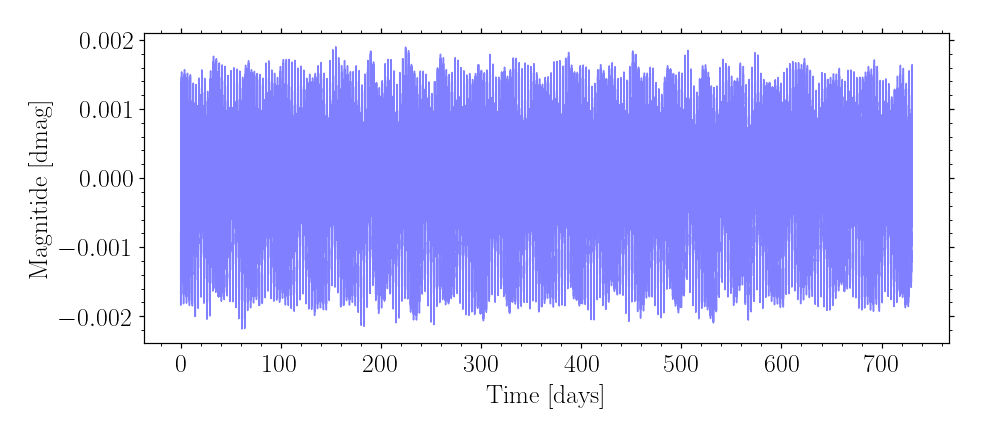

In [35]:
# Show light curve into Plato era
plt.figure(figsize=(9,4))
plt.plot(time, mag, '-', c='b', lw=1, alpha=0.5);
plt.xlabel('Time [days]')
plt.ylabel('Magnitide [dmag]')
plt.tight_layout();

In [36]:
# Save template
dv = pd.DataFrame({'time':time*86400, 'mag':mag})
dv.to_csv(idir / f'varsource_kic5988140.txt', sep=' ', index=False, header=False)

## Reduce simulations

In [102]:
# Pick simulation to reduce
# filename = 'ncam06_mag10'
# filename = 'ncam06_mag15'
# filename = 'ncam06_mag17'
filename = 'ncam24_mag10'
# filename = 'ncam24_mag15'
# filename = 'ncam24_mag17'

In [103]:
# Load light cruves
odir = sdir / filename
lcs = LightCurve(odir, mode='multi')
files = lcs.files(suffix='ftr')
files[0]

'/lhome/nicholas/software/workdir/go_rotmod/sims/ncam24_mag10/000000001_Ncam1.1_Q1.ftr'

In [104]:
# Create table with simulation statistics
dt = lcs.stat_sim_table(ofile=odir/f'table_{filename}.ftr', clean=True)
dt.head()

[Warning]: Remove your "ofile" to use "clean" (if ".table" files still exists)


,ID,PIC,ra,dec,mag,group,camera,quarter,ccd,xCCD,yCCD,rOA,xFP,yFP,ncon,SPR,NSR
0,1,2711012000198,101.954069,-46.325831,10.0,1,1,1,4,343.928744,2954.289016,6.966577,29.302798,7.490717,0,0.0,0.001750
1,1,2711012000198,101.954069,-46.325831,10.0,1,1,2,4,1449.161724,4165.973982,6.543422,7.492468,27.384911,0,0.0,0.001760
2,1,2711012000198,101.954069,-46.325831,10.0,1,1,3,4,2732.951547,3026.554927,13.130348,28.002011,50.493128,0,0.0,0.001811
3,1,2711012000198,101.954069,-46.325831,10.0,1,1,4,4,1593.521581,1773.717173,13.358028,50.553091,29.983388,0,0.0,0.001813
4,1,2711012000198,101.954069,-46.325831,10.0,1,1,5,4,343.928744,2954.289016,6.966577,29.302798,7.490717,0,0.0,0.001756


<IPython.core.display.Javascript object>


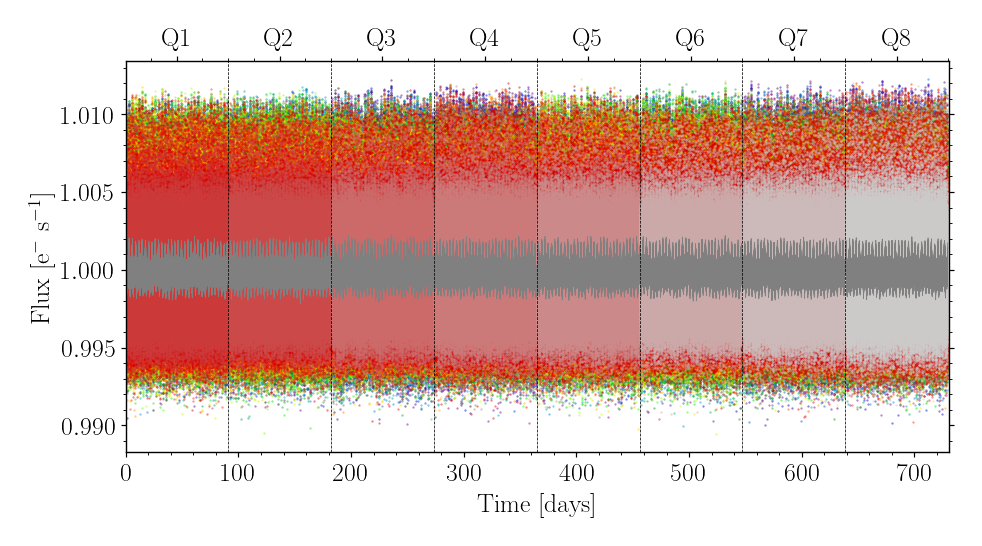

In [105]:
# Show all light curves
fig, ax = lcs.plot_multi(suffix='ftr', group=False, camera=False, quarter=False, 
                         flux_median=144, alpha=0.5, figsize=(9,5));

In [106]:
# Post-processing into final light curve
lc = lcs.merge(
    suffix='ftr',
    flux_group_mean=True,
    binsize=600,
    flux_offset=True,
    flux_error=True,
    ofile=odir/f'lc_{filename}.ftr'
)

Processing star ID 000000001
-------------------------------------------------------
Merging 192 light curves


100%|██████████████████████████████████████████████████| 192/192 [00:16<00:00, 11.74it/s]            


Sorting data after timings
Averaging data from same camera group
Binning data per 600s
Corrrecting flux offset of 1.0 ppm
Calculating flux errors
Saving light curve
Total execution time: 0:00:31.930547 [h:mm:ss]
-------------------------------------------------------


In [107]:
# Get light curve and add time offset since Kepler
df = lc.data()
df.time /= 86400 

<IPython.core.display.Javascript object>


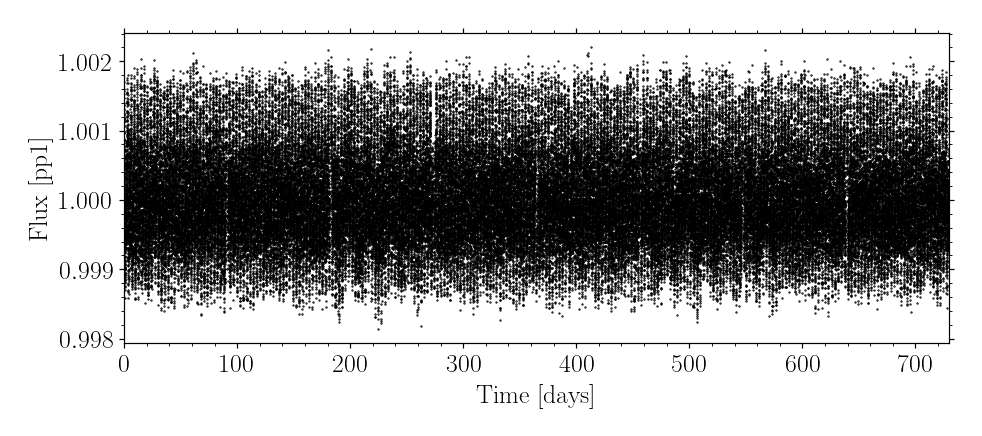

In [108]:
# Show Plato light curve
plt.figure(figsize=(9,4))
plt.plot(df.time, df.flux, 'k.', ms=1)
# plt.plot(dv.time, dv.flux, '-', c='b', lw=1, alpha=0.5);
plt.xlabel('Time [days]')
plt.ylabel('Flux [pp1]')
plt.xlim(0, df.time.max())
plt.tight_layout();